# Data-Analysis on Superstore Dataset:

## Importing Data and Libraries:

In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Default encoding utf-8 was giving error so changed it, as per code provided.

In [306]:
try:
    df = pd.read_csv("../data/superstore.csv", encoding='latin1',on_bad_lines="skip")
    print("Successfully read with latin-1")
except UnicodeDecodeError:
    print("windows-1252 failed")

Successfully read with latin-1


## Information about the Data:

In [307]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [308]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Information of Classes:

In [309]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [310]:
df['Region'].value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

In [311]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

# Data Cleaning:
1. Fix format
2. Remove the duplicates if there is any.
3. Replacing the missing values.

## Fixing the Date formats:

In [312]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [313]:
df[['Row ID','Order Date','Ship Date']]

,Row ID,Order Date,Ship Date
0,1,2016-11-08,2016-11-11
1,2,2016-11-08,2016-11-11
2,3,2016-06-12,2016-06-16
3,4,2015-10-11,2015-10-18
4,5,2015-10-11,2015-10-18
...,...,...,...
9989,9990,2014-01-21,2014-01-23
9990,9991,2017-02-26,2017-03-03
9991,9992,2017-02-26,2017-03-03
9992,9993,2017-02-26,2017-03-03


## Dropping the Duplicates:

In [314]:
df.drop_duplicates(inplace=True)

## Replacing the Missing Values:

In [315]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Here we didn't find any null values so our data is good to go.

# Feature Engineering:

We'll get some derived columns from the exisiting ones:

In [316]:
df['profit_margin'] = df['Profit']/df['Sales']
print(df[['Profit','Sales','profit_margin']])

        Profit     Sales  profit_margin
0      41.9136  261.9600         0.1600
1     219.5820  731.9400         0.3000
2       6.8714   14.6200         0.4700
3    -383.0310  957.5775        -0.4000
4       2.5164   22.3680         0.1125
...        ...       ...            ...
9989    4.1028   25.2480         0.1625
9990   15.6332   91.9600         0.1700
9991   19.3932  258.5760         0.0750
9992   13.3200   29.6000         0.4500
9993   72.9480  243.1600         0.3000

[9994 rows x 3 columns]


In [317]:
df['month'] = df['Order Date'].dt.month
df['year'] = df['Order Date'].dt.year

In [318]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,profit_margin,month,year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600,11,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000,11,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000,10,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125,10,2015


# Exploratory Data Analysis:

## 1. Sales by Region:

In [319]:
df.groupby('Region')['Sales'].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

## 2. Profit by Category:

In [320]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

## 3. Monthly Trend (Sales):

<Axes: xlabel='month'>

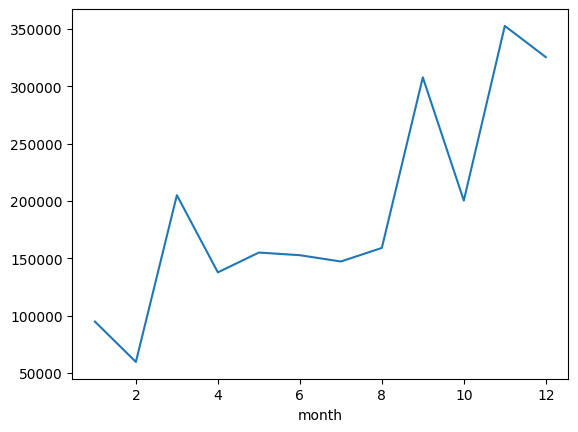

In [321]:
df.groupby('month')['Sales'].sum().plot()

## 4. Discount vs Profit Plotting:

<Axes: xlabel='Discount', ylabel='Profit'>

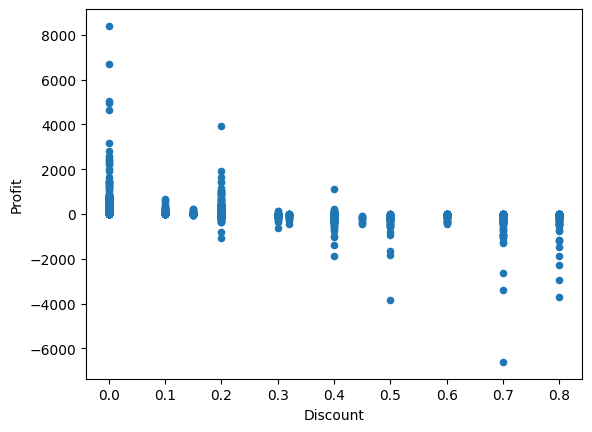

In [322]:
df.plot.scatter(x='Discount',y='Profit')

# Save the Cleaned data and continue the Analysis on SQL:

In [323]:
from pathlib import Path
file_path = Path('../data/cleaned_superstore.csv')
if not file_path.exists():
    print('File does not exists, creating it...')
    df.to_csv('../data/cleaned_superstore.csv',index=False)
else:
    print("File already exists...")

File already exists...
